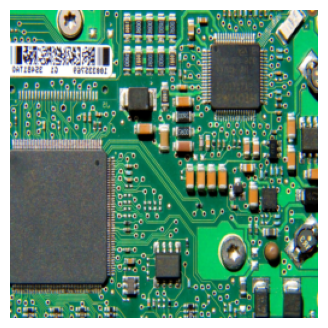

In [ ]:
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

# 전처리
preprocess = T.Compose([
    T.Resize((256, 256)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

image = Image.open('img.jpg')
img_t = preprocess(image)

# 시각화용: 정규화 되돌리기
img_show = img_t * 0.5 + 0.5      # (x-0.5)/0.5 를 역변환

# (C,H,W) -> (H,W,C)
img_show = img_show.permute(1, 2, 0).clamp(0, 1)

plt.figure(figsize=(4,4))
plt.imshow(img_show)
plt.axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


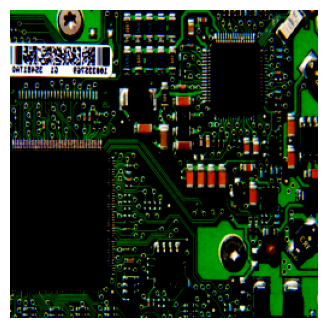

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


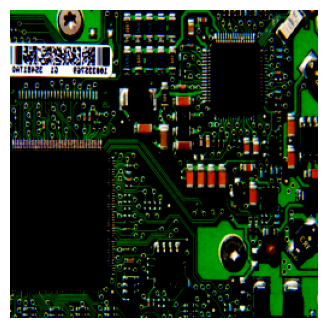

In [ ]:
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

# 전처리
preprocess = T.Compose([
    T.Resize((256, 256)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

image = Image.open('img.jpg')
img_t = preprocess(image)

# 역정규화 없이, 정규화된 텐서 그대로 보기
img_show = img_t.permute(1, 2, 0)   # (C,H,W) -> (H,W,C)
plt.figure(figsize=(4,4))
plt.imshow(img_show)                 # 정규화된 값 그대로 표시
plt.axis('off')
plt.show()

torchvision.utils.save_image 함수는 이미지 텐서를 파일로 저장하는 함수입니다. 이 함수는 주로 딥러닝 모델이 생성한 이미지를 저장할 때 사용됩니다.

torchvision.utils.save_image(tensor, filename, nrow=8, padding=2, normalize=False, range=None, scale_each=False, pad_value=0)


tensor : (Tensor) - 저장할 이미지 텐서. shape는 (batch_size, channels, height, width) 이어야 합니다.
filename : (str) - 저장할 파일의 경로와 이름입니다.
nrow : (int, optional) - 저장할 이미지들을 한 줄에 몇 개씩 보여줄 것인지 결정하는 인자입니다. 기본값은 8입니다.
padding : (int, optional) - 이미지들 사이의 간격을 몇 개의 픽셀로 할 것인지 결정하는 인자입니다. 기본값은 2입니다.
normalize : (bool, optional) - 이미지의 값을 [0, 1]로 정규화할 것인지 결정하는 인자입니다. 기본값은 True입니다.
range : (tuple, optional) - 이미지를 정규화할 때 사용할 범위를 결정하는 인자입니다. 기본값은 None으로, 입력된 텐서의 값 범위를 그대로 사용합니다.
scale_each : (bool, optional) - 이미지를 정규화할 때 각 이미지마다 다른 범위를 사용할지 여부를 결정하는 인자입니다. 기본값은 False입니다.
pad_value : (float, optional) - 이미지의 테두리를 채우는 값입니다. 기본값은 0입니다.

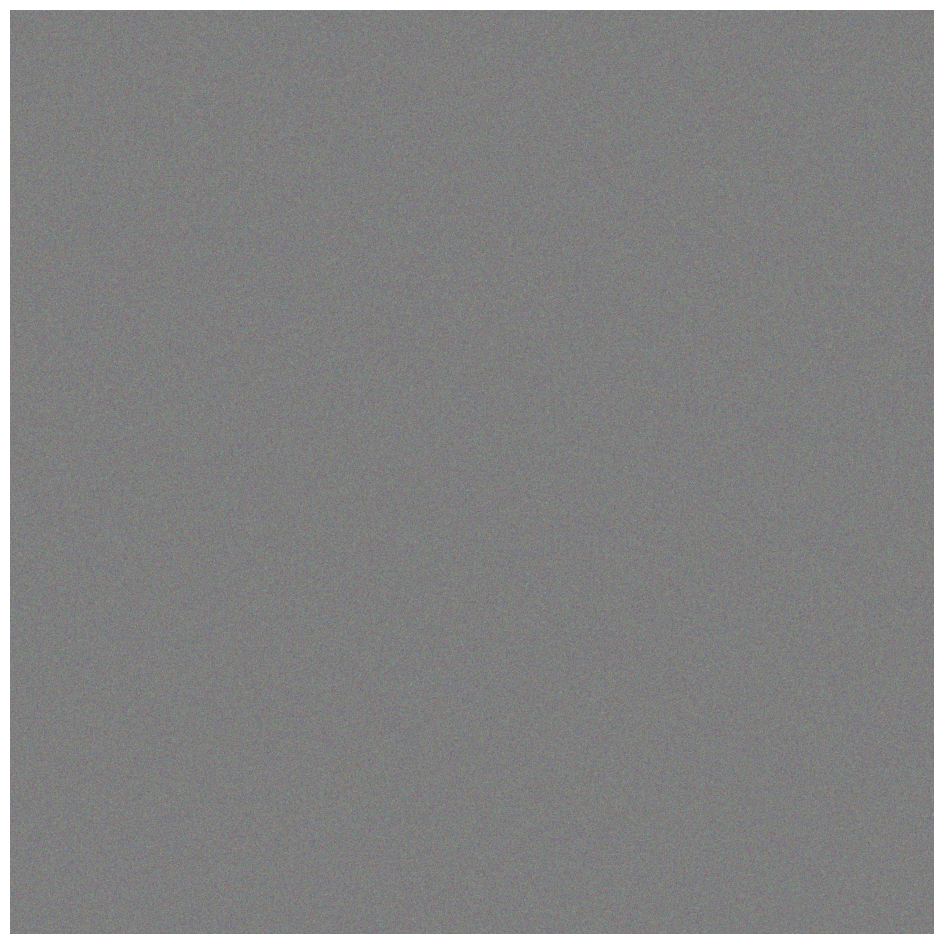

In [72]:
import torch
import matplotlib.pyplot as plt

# Create a tensor of shape (3, 64, 64) representing a single RGB image
img = torch.randn(3, 2048, 2048)

# [0,1] 범위로 스케일
img_show = (img - img.min()) / (img.max() - img.min())

# (C,H,W) -> (H,W,C)
img_show = img_show.permute(1, 2, 0)

plt.figure(figsize=(12,12))
plt.imshow(img_show)
plt.axis('off')
plt.show()


